## Sistem Identifikasi Suara Terbatas untuk Pengguna Tertentu (Minimal 2 Orang)

### Tahap 1 — Import Library
Librosa untuk audio, SciPy untuk statistik sinyal, Scikit-learn untuk ML, dan Joblib untuk menyimpan model.

In [19]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib


### Tahap 2 — Eksplorasi Struktur Dataset

### Augmentasi

In [20]:
import os
import shutil

# Folder utama tempat menyimpan suara
base_folder = "suara"

# Target jumlah file minimum per kategori
target = 110

# Loop untuk tiap orang
for person in os.listdir(base_folder):
    person_path = os.path.join(base_folder, person)
    if os.path.isdir(person_path):
        
        # Loop untuk tiap perintah (buka/tutup)
        for command in os.listdir(person_path):
            command_path = os.path.join(person_path, command)
            if os.path.isdir(command_path):
                files = [f for f in os.listdir(command_path) if f.endswith(".wav")]
                count = len(files)

                print(f"{person}/{command}: {count} file ditemukan.")

                # Jika kurang dari target, duplikasi
                if count < target:
                    needed = target - count
                    print(f"  ➤ Menambahkan {needed} file agar total menjadi {target}.")

                    for i in range(needed):
                        src = os.path.join(command_path, files[i % count])  # duplikasi merata
                        dst = os.path.join(command_path, f"dupe_{i}.wav")
                        shutil.copy(src, dst)

                else:
                    print(f"  ✅ Sudah cukup ({count} file).")

print("\nProses selesai! Semua folder kini memiliki minimal 110 file.")


Vanisa/Tutup: 110 file ditemukan.
  ✅ Sudah cukup (110 file).
Vanisa/Buka: 110 file ditemukan.
  ✅ Sudah cukup (110 file).
Nadia/buka: 110 file ditemukan.
  ✅ Sudah cukup (110 file).
Nadia/tutup: 110 file ditemukan.
  ✅ Sudah cukup (110 file).

Proses selesai! Semua folder kini memiliki minimal 110 file.


In [21]:
base_folder = "suara"

for speaker in os.listdir(base_folder):
    speaker_path = os.path.join(base_folder, speaker)
    if os.path.isdir(speaker_path):

        print(f"\n🎤 Speaker: {speaker}")

        for command in os.listdir(speaker_path):
            command_path = os.path.join(speaker_path, command)

            if os.path.isdir(command_path):
                files = [f for f in os.listdir(command_path) if f.endswith(".wav")]
                print(f"   🎧 {command}: {len(files)} file ditemukan")




🎤 Speaker: Vanisa
   🎧 Tutup: 110 file ditemukan
   🎧 Buka: 110 file ditemukan

🎤 Speaker: Nadia
   🎧 buka: 110 file ditemukan
   🎧 tutup: 110 file ditemukan


### Tahap 3: Preprocessing Audio
Langkah ini akan:

- Menyeragamkan sampling rate

- Menghapus bagian diam

- Menormalkan amplitudo

- Menyimpan ulang hasil yang sudah bersih

In [22]:
import os
import librosa
import soundfile as sf
from tqdm import tqdm

def preprocess_audio(input_path, output_path, sr_target=22050):
    """
    Membersihkan dan menyeragamkan file audio hingga level subfolder terdalam:
    - Convert ke mono
    - Sampling rate seragam
    - Hapus bagian diam
    - Normalisasi amplitudo
    """
    for root, dirs, files in os.walk(input_path):  # berjalan sampai ke subfolder terdalam
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                rel_path = os.path.relpath(root, input_path)  # path relatif
                save_dir = os.path.join(output_path, rel_path)
                os.makedirs(save_dir, exist_ok=True)

                try:
                    y, sr = librosa.load(file_path, sr=sr_target)
                    y, _ = librosa.effects.trim(y)
                    y = librosa.util.normalize(y)

                    save_path = os.path.join(save_dir, file)
                    sf.write(save_path, y, sr)
                except Exception as e:
                    print(f"❌ Gagal memproses {file_path}: {e}")

    print("✅ Preprocessing selesai. File hasil disimpan di folder:", output_path)


# Jalankan
preprocess_audio("suara", "clean_audio")


✅ Preprocessing selesai. File hasil disimpan di folder: clean_audio


### Tahap 4: Cek hasil preprocessing

In [23]:
import os

base_folder = "clean_audio"

for person in os.listdir(base_folder):
    folder = os.path.join(base_folder, person)
    
    if not os.path.isdir(folder):
        continue  # lewati kalau bukan folder

    for sub in os.listdir(folder):
        subfolder = os.path.join(folder, sub)
        
        if not os.path.isdir(subfolder):
            continue  # lewati kalau bukan folder

        files = [f for f in os.listdir(subfolder) if f.endswith(".wav")]
        for file in files:
            file_path = os.path.join(subfolder, file)
            print(file_path)


clean_audio/Vanisa/Tutup/dupe_83.wav
clean_audio/Vanisa/Tutup/36.wav
clean_audio/Vanisa/Tutup/dupe_79.wav
clean_audio/Vanisa/Tutup/dupe_26.wav
clean_audio/Vanisa/Tutup/dupe_72.wav
clean_audio/Vanisa/Tutup/dupe_84.wav
clean_audio/Vanisa/Tutup/dupe_39.wav
clean_audio/Vanisa/Tutup/dupe_5.wav
clean_audio/Vanisa/Tutup/dupe_30.wav
clean_audio/Vanisa/Tutup/dupe_36.wav
clean_audio/Vanisa/Tutup/dupe_28.wav
clean_audio/Vanisa/Tutup/dupe_9.wav
clean_audio/Vanisa/Tutup/37.wav
clean_audio/Vanisa/Tutup/dupe_3.wav
clean_audio/Vanisa/Tutup/dupe_55.wav
clean_audio/Vanisa/Tutup/dupe_37.wav
clean_audio/Vanisa/Tutup/dupe_61.wav
clean_audio/Vanisa/Tutup/dupe_0.wav
clean_audio/Vanisa/Tutup/dupe_19.wav
clean_audio/Vanisa/Tutup/dupe_23.wav
clean_audio/Vanisa/Tutup/44.wav
clean_audio/Vanisa/Tutup/40.wav
clean_audio/Vanisa/Tutup/dupe_17.wav
clean_audio/Vanisa/Tutup/dupe_4.wav
clean_audio/Vanisa/Tutup/dupe_58.wav
clean_audio/Vanisa/Tutup/dupe_13.wav
clean_audio/Vanisa/Tutup/dupe_66.wav
clean_audio/Vanisa/Tutup/d

### Tahap 5: Visualisasi Bentuk Gelombang (Waveform & Spectrogram)
Untuk melihat perbedaan karakteristik sinyal antara suara “buka” dan “tutup”.

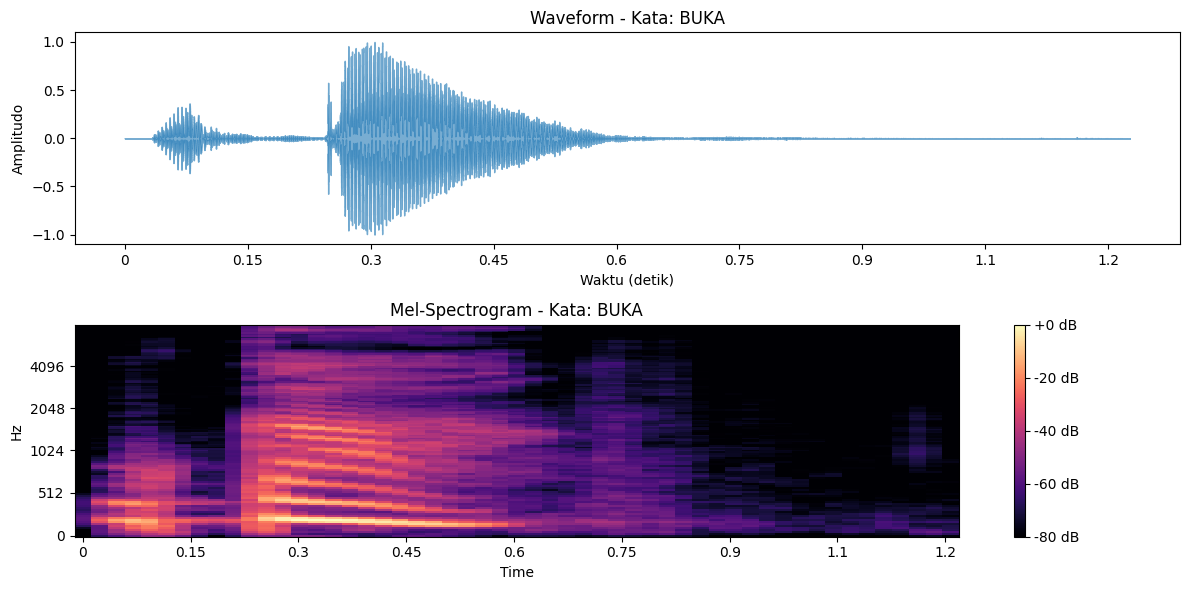

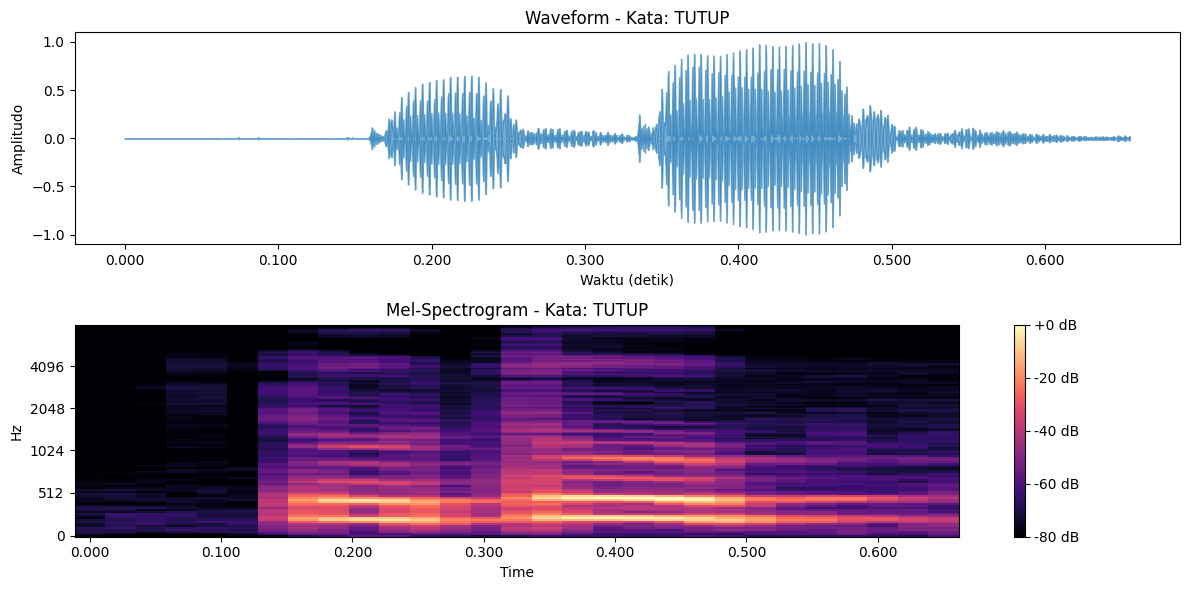

In [24]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

# Pilih contoh file dari setiap kelas
file_buka = "clean_audio/Nadia/buka/buka 1.wav"   # ubah sesuai nama file kamu
file_tutup = "clean_audio/Nadia/tutup/tutup1.wav"

# Fungsi bantu untuk visualisasi
def plot_waveform_and_spectrogram(file_path, title):
    y, sr = librosa.load(file_path, sr=None)

    plt.figure(figsize=(12, 6))
    
    # --- Plot Waveform ---
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"Waveform - {title}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")
    
    # --- Plot Spectrogram ---
    plt.subplot(2, 1, 2)
    spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    librosa.display.specshow(spec_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000, cmap="magma")
    plt.title(f"Mel-Spectrogram - {title}")
    plt.colorbar(format="%+2.0f dB")
    
    plt.tight_layout()
    plt.show()


# --- Tampilkan visualisasi ---
plot_waveform_and_spectrogram(file_buka, "Kata: BUKA")
plot_waveform_and_spectrogram(file_tutup, "Kata: TUTUP")


### Tahap 6: Ekstraksi Fitur Audio

Mengubah setiap file .wav menjadi vektor numerik yang menggambarkan ciri khas suara (misalnya nada, tempo, energi, dll).

💡 Fitur yang Akan Diekstrak:

- ZCR (Zero Crossing Rate) → seberapa sering sinyal berganti tanda (+/-)

- RMS (Root Mean Square Energy) → energi rata-rata sinyal

- Spectral Centroid → pusat energi spektrum (nada rata-rata)

- Spectral Bandwidth → sebaran frekuensi

- Spectral Contrast → kontras antara puncak dan lembah energi

- MFCC (Mel-Frequency Cepstral Coefficients) → fitur utama untuk pengenalan suara (biasanya 13–20 koefisien)

In [25]:
# ====================================================
# 🎯 TAHAP 6 — EKSTRAKSI FITUR AUDIO (PERBAIKAN FINAL)
# ====================================================

import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

# Folder hasil preprocessing
base_path = "clean_audio"

# -------------------------------
# 🔹 Fungsi bantu ekstraksi fitur
# -------------------------------

def zero_crossing_rate(y):
    """Menghitung Zero Crossing Rate"""
    return np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)[0]

def rms(signal):
    """Menghitung Root Mean Square (energi sinyal)"""
    return np.sqrt(np.mean(signal**2))

def spectral_centroid(y, sr):
    """Rata-rata spectral centroid"""
    return np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

def spectral_bandwidth(y, sr):
    """Rata-rata spectral bandwidth"""
    return np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))

def spectral_contrast(y, sr):
    """Rata-rata spectral contrast"""
    return np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))

def mfcc_features(y, sr, n_mfcc=13):
    """Rata-rata dari MFCC coefficients"""
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfccs, axis=1)  # hasil 13 dimensi

# ---------------------------------------------------
# 🔹 Proses semua file dan ekstraksi fitur numeriknya
# ---------------------------------------------------

features = []

# Loop per orang (misal Nadia, Vanisa)
for person in os.listdir(base_path):
    person_folder = os.path.join(base_path, person)
    if not os.path.isdir(person_folder):
        continue

    # Loop ke dalam subfolder (misal buka, tutup)
    for subfolder in os.listdir(person_folder):
        sub_path = os.path.join(person_folder, subfolder)
        if not os.path.isdir(sub_path):
            continue

        # Loop tiap file .wav di subfolder
        for file in tqdm(os.listdir(sub_path), desc=f"Ekstraksi fitur {person}/{subfolder}"):
            if file.endswith(".wav"):
                file_path = os.path.join(sub_path, file)
                try:
                    y, sr = librosa.load(file_path, sr=22050)

                    # Ambil fitur utama
                    zcr = zero_crossing_rate(y)
                    energy = rms(y)
                    sc = spectral_centroid(y, sr)
                    sb = spectral_bandwidth(y, sr)
                    scon = spectral_contrast(y, sr)
                    mfccs = mfcc_features(y, sr)

                    # Gabungkan semua fitur
                    data_row = [f"{person}_{subfolder}", zcr, energy, sc, sb, scon] + mfccs.tolist()
                    features.append(data_row)

                except Exception as e:
                    print(f"❌ Gagal ekstraksi {file_path}: {e}")

# ---------------------------------------
# 🔹 Simpan hasil fitur ke dataframe CSV
# ---------------------------------------

columns = ['label', 'zcr', 'rms', 'spectral_centroid', 'spectral_bandwidth', 'spectral_contrast'] \
          + [f'mfcc_{i+1}' for i in range(13)]

df_features = pd.DataFrame(features, columns=columns)

# Simpan ke file CSV
df_features.to_csv("audio_features.csv", index=False)
print(f"✅ Ekstraksi fitur selesai ({len(df_features)} file berhasil) dan disimpan ke 'audio_features.csv'")


Ekstraksi fitur Nadia/tutup: 100%|██████████| 110/110 [00:01<00:00, 79.52it/s]

✅ Ekstraksi fitur selesai (440 file berhasil) dan disimpan ke 'audio_features.csv'


### Tahap 7 — EDA (Exploratory Data Analysis)

Tujuan: memahami bagaimana perbedaan karakteristik fitur antar suara, Tahap ini membantu kamu melihat fitur mana yang paling membedakan suara antar orang atau antar kata.

📊 INFORMASI DATASET
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   label               440 non-null    object 
 1   zcr                 440 non-null    float64
 2   rms                 440 non-null    float64
 3   spectral_centroid   440 non-null    float64
 4   spectral_bandwidth  440 non-null    float64
 5   spectral_contrast   440 non-null    float64
 6   mfcc_1              440 non-null    float64
 7   mfcc_2              440 non-null    float64
 8   mfcc_3              440 non-null    float64
 9   mfcc_4              440 non-null    float64
 10  mfcc_5              440 non-null    float64
 11  mfcc_6              440 non-null    float64
 12  mfcc_7              440 non-null    float64
 13  mfcc_8              440 non-null    float64
 14  mfcc_9              440 non-null   

/tmp/ipykernel_2666/1512122122.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="label", palette="viridis", edgecolor="black")


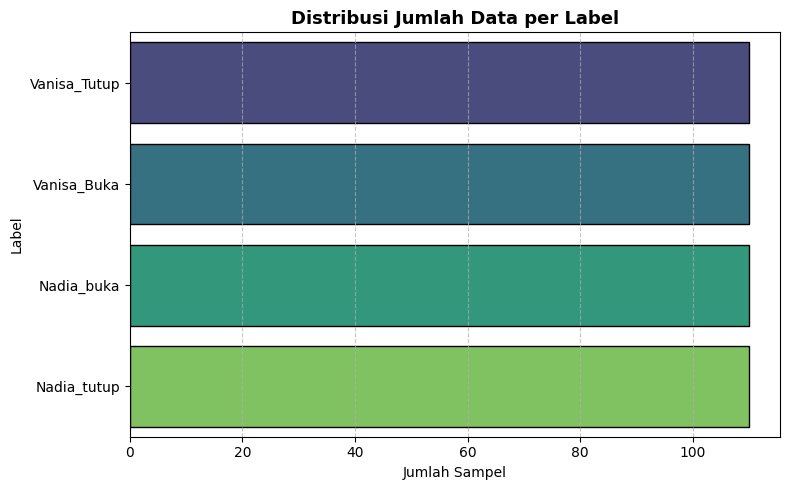

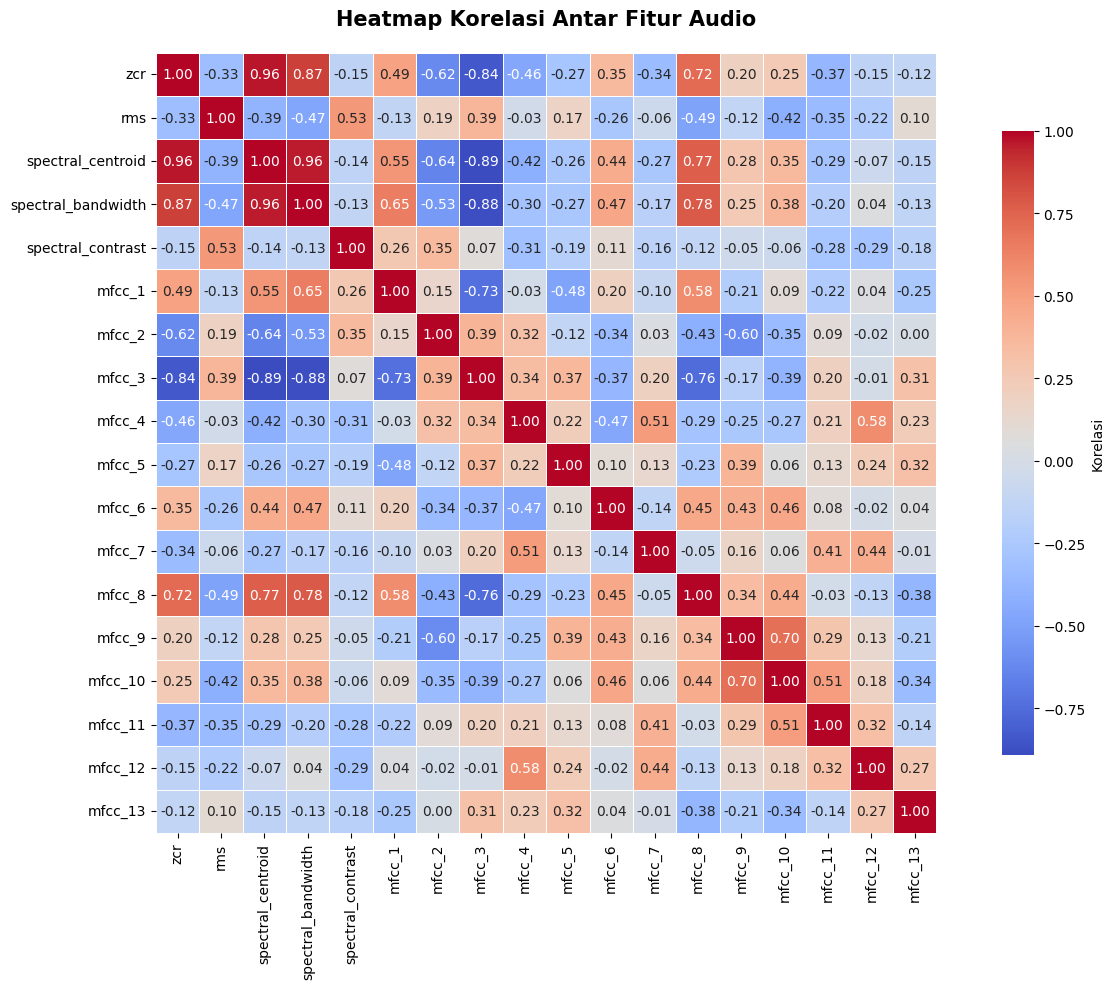

/tmp/ipykernel_2666/1512122122.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feature, palette="Set2")


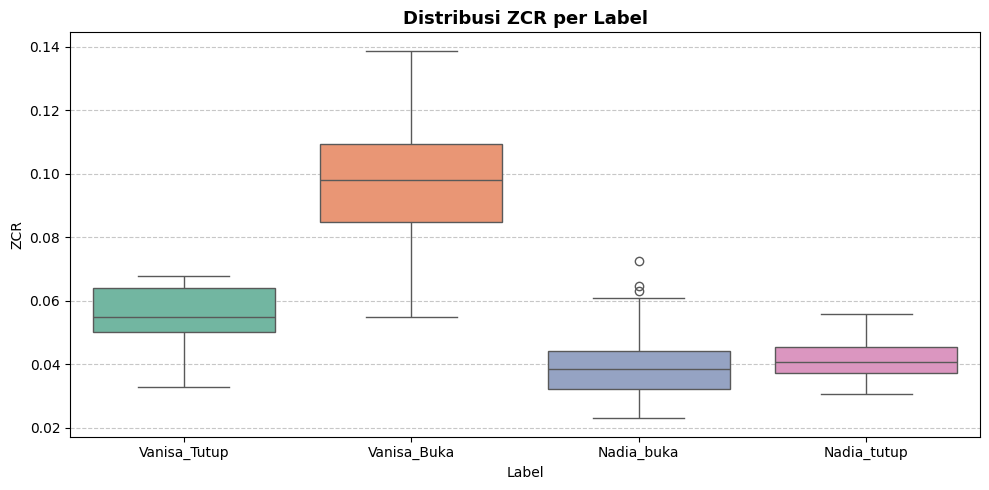

/tmp/ipykernel_2666/1512122122.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feature, palette="Set2")


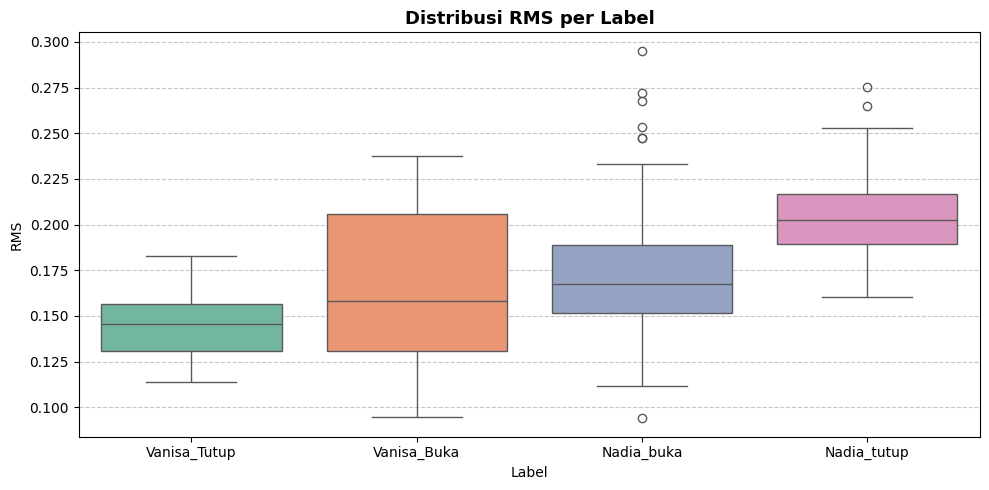

/tmp/ipykernel_2666/1512122122.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feature, palette="Set2")


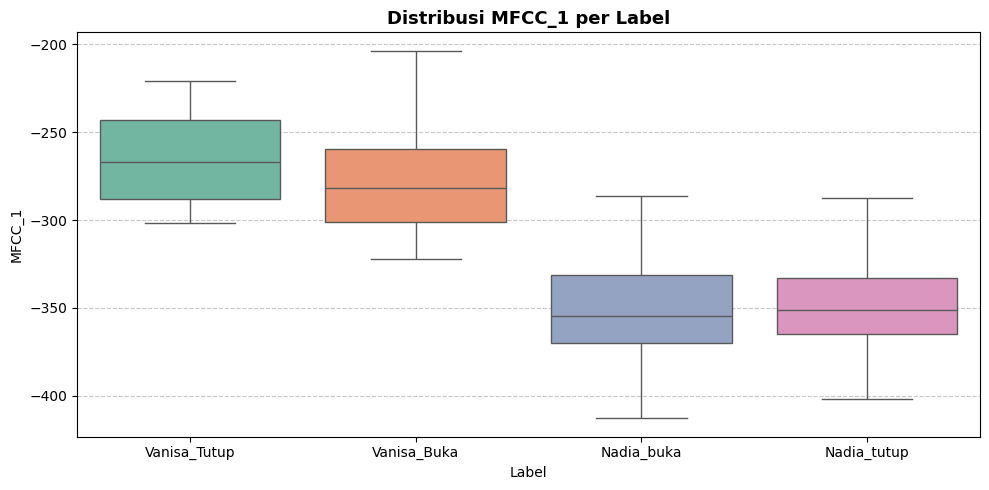

/tmp/ipykernel_2666/1512122122.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feature, palette="Set2")


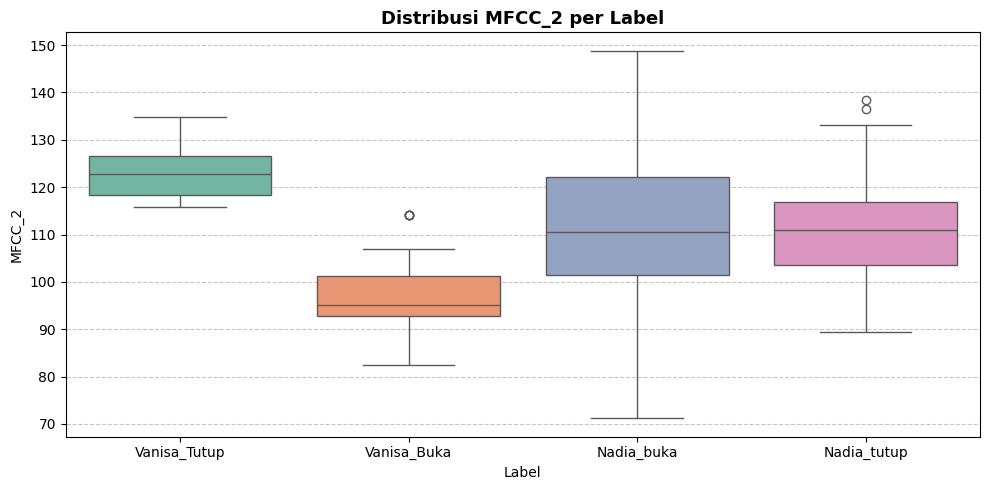

/tmp/ipykernel_2666/1512122122.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feature, palette="Set2")


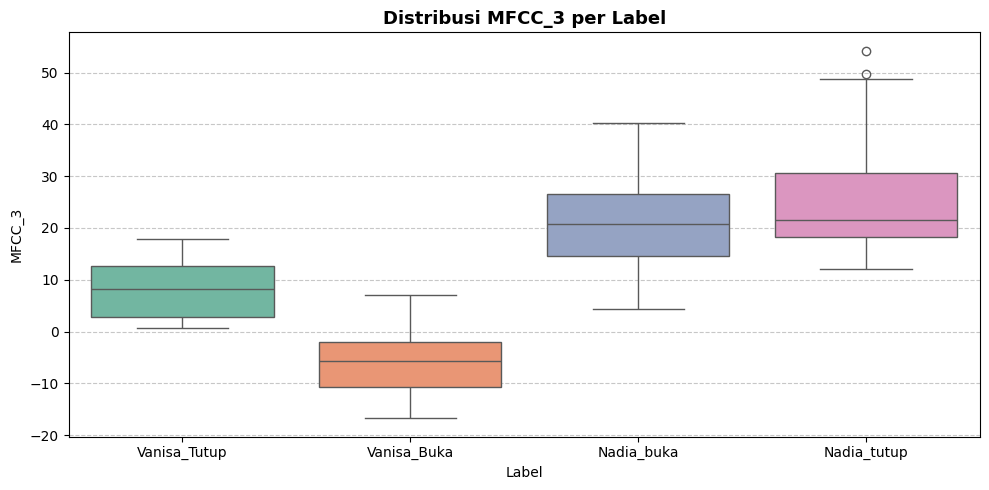

📈 STATISTIK DESKRIPTIF FITUR
--------------------------------------------------
                    count         mean         std          min          25%  \
zcr                 440.0     0.058539    0.027046     0.022931     0.039233   
rms                 440.0     0.172209    0.037676     0.094053     0.144873   
spectral_centroid   440.0  1479.283994  451.322769   675.624102  1143.319764   
spectral_bandwidth  440.0  1919.771830  343.312385  1127.186067  1651.727676   
spectral_contrast   440.0    18.807173    0.622587    17.201660    18.395338   
mfcc_1              440.0  -310.618318   47.200538  -412.729095  -352.355156   
mfcc_2              440.0   110.230675   14.315703    71.222153    99.151962   
mfcc_3              440.0    12.263555   13.935786   -16.728512     2.312081   
mfcc_4              440.0    13.571206    9.211579   -10.987894     5.788668   
mfcc_5              440.0    -0.159648    5.491087   -13.502519    -2.966663   
mfcc_6              440.0    -0.131056  

/tmp/ipykernel_2666/1512122122.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_df, x="Jumlah Outlier", y="Fitur", palette="rocket", edgecolor="black")


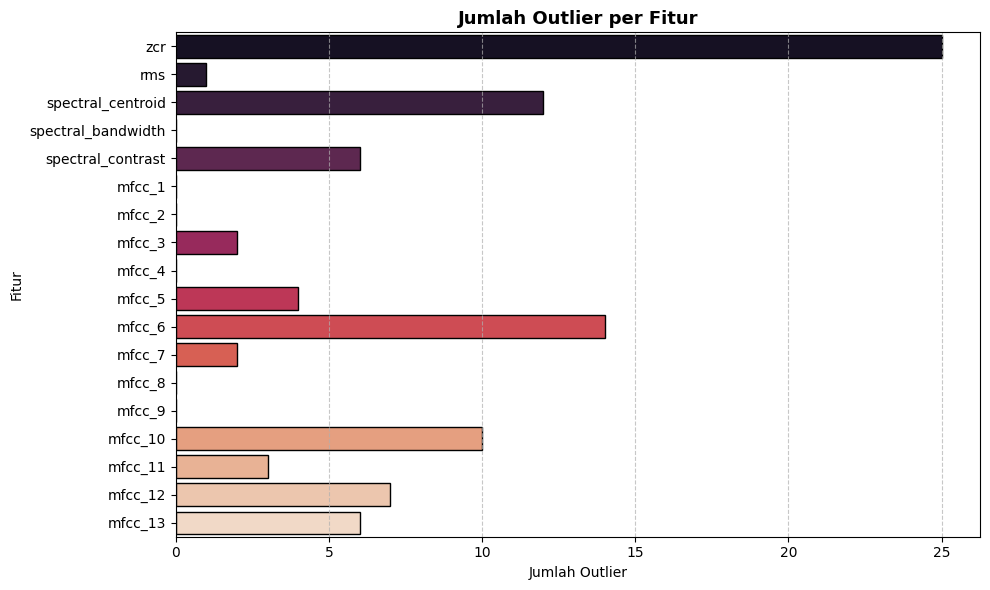

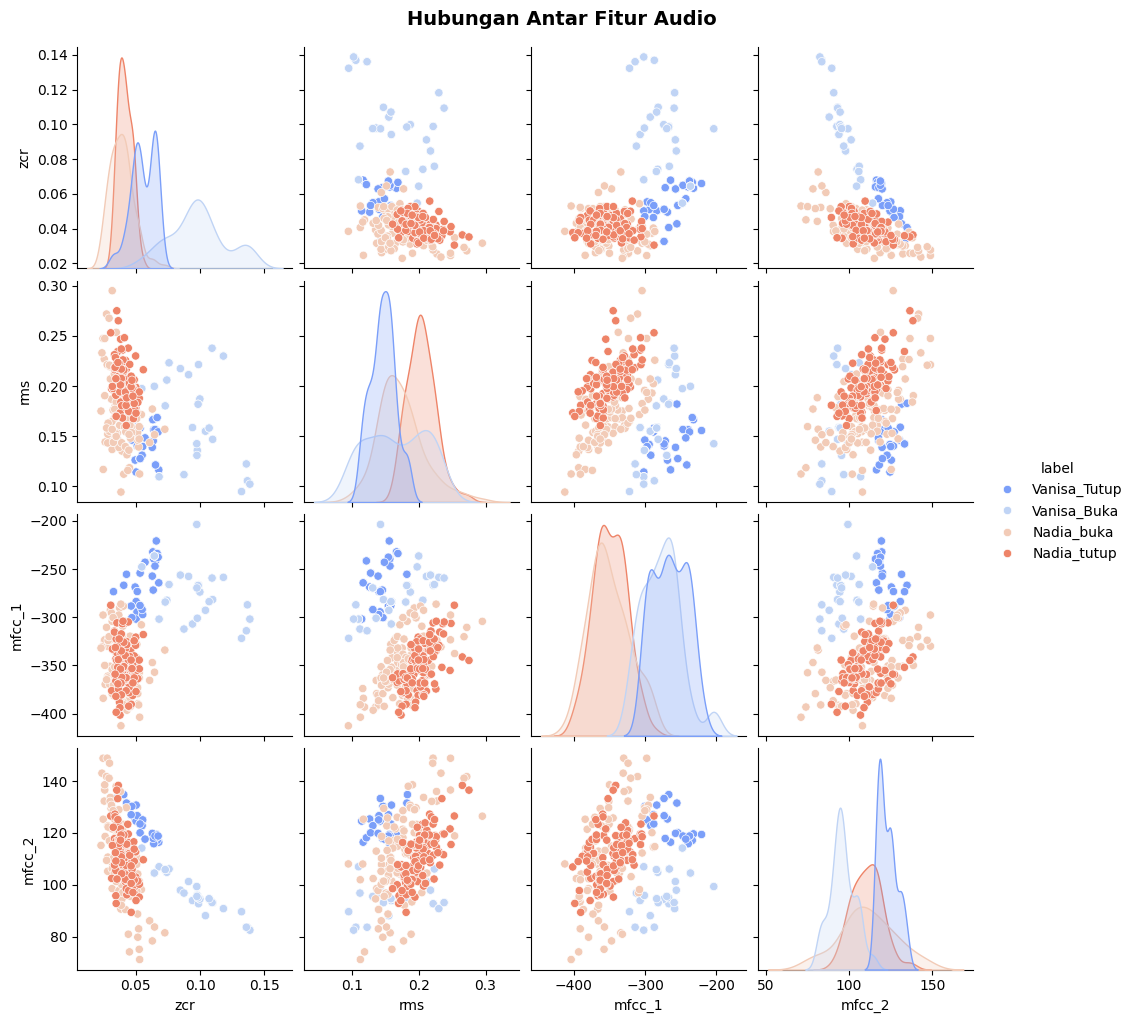

In [26]:
# ====================================================
# 🎯 TAHAP 7 — EDA (EXPLORATORY DATA ANALYSIS)
# ====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 🔹 1. Load dataset hasil ekstraksi fitur
# -------------------------------
df = pd.read_csv("audio_features.csv")

print("📊 INFORMASI DATASET")
print("-" * 50)
print(df.info())
print("\n🔍 CONTOH DATA:")
print(df.head(), "\n")

# Pastikan kolom label ada
if 'label' not in df.columns:
    raise ValueError("Kolom 'label' tidak ditemukan! Pastikan hasil ekstraksi fitur benar.")

# -------------------------------
# 🔹 2. Distribusi jumlah data per label
# -------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="label", palette="viridis", edgecolor="black")
plt.title("Distribusi Jumlah Data per Label", fontsize=13, weight="bold")
plt.xlabel("Jumlah Sampel")
plt.ylabel("Label")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -------------------------------
# 🔹 3. Heatmap Korelasi Antar Fitur Numerik (lebih tajam & rapi)
# -------------------------------
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,          # tampilkan nilai korelasi
    fmt=".2f",           # dua angka di belakang koma
    linewidths=0.5,      # garis pembatas antar sel
    square=True,         # bentuk kotak
    cbar_kws={"shrink": 0.8, "label": "Korelasi"}
)
plt.title("Heatmap Korelasi Antar Fitur Audio", fontsize=15, weight="bold", pad=20)
plt.tight_layout()
plt.show()

# -------------------------------
# 🔹 4. Visualisasi beberapa fitur utama (MFCC & ZCR)
# -------------------------------
for feature in ["zcr", "rms", "mfcc_1", "mfcc_2", "mfcc_3"]:
    if feature in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x="label", y=feature, palette="Set2")
        plt.title(f"Distribusi {feature.upper()} per Label", fontsize=13, weight="bold")
        plt.xlabel("Label")
        plt.ylabel(feature.upper())
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

# -------------------------------
# 🔹 5. Statistik deskriptif fitur numerik
# -------------------------------
print("📈 STATISTIK DESKRIPTIF FITUR")
print("-" * 50)
print(df.describe().T)

# -------------------------------
# 🔹 6. Deteksi & Hitung Jumlah Outlier per Fitur (metode IQR)
# -------------------------------
print("\n🚨 DETEKSI OUTLIER PER FITUR")
print("-" * 50)

outlier_data = []
total_rows = len(df)

for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    count = len(outliers)
    percent = (count / total_rows) * 100
    outlier_data.append([col, count, f"{percent:.2f}%"])

# Buat DataFrame hasil outlier
outlier_df = pd.DataFrame(outlier_data, columns=["Fitur", "Jumlah Outlier", "Persentase Outlier"])
print(outlier_df.to_string(index=False))

# Visualisasi jumlah outlier per fitur
plt.figure(figsize=(10, 6))
sns.barplot(data=outlier_df, x="Jumlah Outlier", y="Fitur", palette="rocket", edgecolor="black")
plt.title("Jumlah Outlier per Fitur", fontsize=13, weight="bold")
plt.xlabel("Jumlah Outlier")
plt.ylabel("Fitur")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -------------------------------
# 🔹 7. (Opsional) Pairplot untuk visualisasi hubungan antar fitur
# -------------------------------
try:
    sns.pairplot(
        df[["zcr", "rms", "mfcc_1", "mfcc_2", "label"]],
        hue="label",
        palette="coolwarm",
        diag_kind="kde"
    )
    plt.suptitle("Hubungan Antar Fitur Audio", y=1.02, fontsize=14, weight="bold")
    plt.show()
except Exception as e:
    print(f"⚠️ Pairplot dilewati karena error: {e}")


### Tahap 8: Train Test Split
test_size=0.2 → 20% data untuk testing, 80% untuk training

stratify=y → memastikan distribusi label di train dan test tetap seimbang

random_state=42 → supaya hasil split konsisten setiap kali dijalankan

Setelah ini, X_train, X_test, y_train, dan y_test siap dipakai untuk training model klasifikasi.

In [27]:
# ==================================================
# 🔹 IMPORT LIBRARY
# ==================================================
import pandas as pd
from sklearn.model_selection import train_test_split

# ==================================================
# 🔹 1. LOAD DATASET FITUR AUDIO
# ==================================================
df_features = pd.read_csv("audio_features.csv")
print("✅ Data fitur berhasil dimuat:")
display(df_features.head())

# ==================================================
# 🔹 2. PISAHKAN FITUR DAN LABEL
# ==================================================
X = df_features.drop(columns=['label'])
y = df_features['label']

# ==================================================
# 🔹 3. TRAIN-TEST SPLIT
# ==================================================
# 80% data training, 20% data testing
# Stratify = menjaga proporsi label agar seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# 🔹 4. CEK HASIL SPLIT
# ==================================================
print("✅ Data berhasil di-split!")
print(f"Jumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")
print("\n🔍 Contoh data training:")
display(X_train.head())
print("\n🔍 Contoh data testing:")
display(X_test.head())


✅ Data fitur berhasil dimuat:


,label,zcr,rms,spectral_centroid,spectral_bandwidth,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,Vanisa_Tutup,0.049507,0.125984,1454.048021,2078.377451,18.321114,-268.688171,125.369102,10.087667,21.354322,-0.642616,2.520404,0.458828,-8.783010,-18.753090,-7.350034,-11.432769,-4.396814,-8.098873
1,Vanisa_Tutup,0.062843,0.138686,1604.376863,2098.004848,18.449672,-257.350616,119.841354,2.749013,22.116590,-10.704468,-3.138860,9.616466,-1.900774,-15.357807,-11.264039,-12.687927,-7.589251,-11.424817
2,Vanisa_Tutup,0.064015,0.156282,1627.472509,2127.443676,18.687709,-239.529114,115.841377,4.906523,20.325714,-10.296597,-4.253180,3.702055,-1.526075,-20.345367,-12.646870,-13.991186,-6.347251,-13.789545
3,Vanisa_Tutup,0.063566,0.145146,1580.935138,2031.770609,18.995097,-271.856964,117.874214,2.189959,21.930073,-8.171942,-9.025284,1.033189,-3.395963,-15.516003,-10.831207,-15.707949,-7.911689,-9.299342
4,Vanisa_Tutup,0.046406,0.154104,1346.643150,1982.608045,18.923212,-288.443451,127.009575,15.127504,18.345840,-1.786182,0.912792,2.828473,-11.928684,-16.382843,-8.435550,-10.662820,-4.011746,-7.044550


✅ Data berhasil di-split!
Jumlah data training : 352
Jumlah data testing  : 88

🔍 Contoh data training:


,zcr,rms,spectral_centroid,spectral_bandwidth,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
423,0.048804,0.182530,1301.549165,1702.252936,18.117018,-363.055389,101.799515,23.214880,20.367310,4.255418,-5.525286,1.987425,-16.943417,-15.542488,-12.162926,-13.127871,-5.019482,-3.871519
367,0.040747,0.214618,1217.837923,1776.634074,18.723932,-334.607239,109.675148,18.201416,21.054302,10.326548,-7.908155,6.966186,-17.385138,-9.668155,-11.604367,-14.334274,-2.118298,-4.318317
39,0.062843,0.138686,1604.376863,2098.004848,18.449672,-257.350616,119.841354,2.749013,22.116590,-10.704468,-3.138860,9.616466,-1.900774,-15.357807,-11.264039,-12.687927,-7.589251,-11.424817
325,0.052659,0.147000,1256.687883,1708.346083,18.180126,-363.113617,101.416313,21.817228,9.126031,-3.801340,3.087960,-6.398973,-16.071560,-3.286824,3.604620,-9.548670,-5.256666,-10.032592
23,0.064015,0.156282,1627.472509,2127.443676,18.687709,-239.529114,115.841377,4.906523,20.325714,-10.296597,-4.253180,3.702055,-1.526075,-20.345367,-12.646870,-13.991186,-6.347251,-13.789545



🔍 Contoh data testing:


,zcr,rms,spectral_centroid,spectral_bandwidth,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
329,0.033594,0.176729,1002.743560,1551.331292,19.766879,-351.563019,125.226036,32.999142,13.402209,-7.347831,-3.991538,8.189779,-1.476072,-1.413106,-6.133430,-9.644629,-5.880235,-10.739511
432,0.034131,0.228441,974.951131,1455.104517,19.710219,-331.533203,112.389076,28.683723,18.500719,-4.696643,-3.078937,5.707322,-25.340792,-18.030020,-14.228753,-21.625208,-5.923501,-7.494741
34,0.065366,0.121140,1693.460597,2185.679678,18.683460,-241.563812,118.141144,2.312081,17.403627,-10.106564,-1.768064,5.980227,-2.167029,-18.626011,-8.427271,-13.443599,-7.996668,-14.632721
366,0.037720,0.173171,986.548204,1464.670762,18.105536,-401.624237,106.885284,36.583889,13.841311,5.048841,4.214321,3.432169,-18.623833,-20.626762,-17.086962,-15.566890,-10.620341,-4.569761
401,0.041174,0.248190,1183.404565,1699.179226,19.679232,-306.467194,115.543510,14.873791,25.296402,4.275884,-5.268802,9.015927,-24.896032,-13.502984,-10.055726,-19.202614,0.986106,-8.412015


### Tahap 9 — Normalisasi Data

In [29]:
# ==================================================
# 🔹 4. NORMALISASI FITUR (SETELAH SPLIT)
# ==================================================
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# Buat objek StandardScaler
scaler = StandardScaler()

# Fit hanya di data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform juga data test berdasarkan skala dari training
X_test_scaled = scaler.transform(X_test)

# ==================================================
# 🔹 5. SIMPAN SCALER UNTUK PREDIKSI AUDIO BARU
# ==================================================
joblib.dump(scaler, "scaler_audio.pkl")
print("✅ Scaler berhasil disimpan sebagai 'scaler_audio.pkl'")

# ==================================================
# 🔹 6. (OPSIONAL) BUAT DATAFRAME UNTUK DILIHAT
# ==================================================
df_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
df_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Gabungkan label supaya bisa dianalisis
df_train_scaled["label"] = y_train.reset_index(drop=True)
df_test_scaled["label"] = y_test.reset_index(drop=True)

print("\n✅ Contoh data hasil normalisasi (training set):")
display(df_train_scaled.head())


✅ Scaler berhasil disimpan sebagai 'scaler_audio.pkl'

✅ Contoh data hasil normalisasi (training set):


,zcr,rms,spectral_centroid,spectral_bandwidth,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,label
0,-0.355673,0.259385,-0.384180,-0.620783,-1.109189,-1.133571,-0.609830,0.778283,0.714901,0.766191,-1.042821,0.068003,-0.937445,-0.749461,-0.859132,0.222810,0.502371,1.803642,Nadia_tutup
1,-0.650243,1.098934,-0.567435,-0.406399,-0.148672,-0.518511,-0.060447,0.418389,0.786668,1.845293,-1.507490,1.151427,-0.987086,0.208163,-0.757172,-0.097898,1.278617,1.670679,Nadia_tutup
2,0.157635,-0.887767,0.278751,0.519866,-0.582722,1.151810,0.648721,-0.690869,0.897642,-1.892827,-0.577458,1.728153,0.753074,-0.719354,-0.695048,0.339764,-0.185201,-0.444146,Vanisa_Tutup
3,-0.214729,-0.670242,-0.482387,-0.603221,-1.009312,-1.134830,-0.636561,0.677952,-0.459435,-0.665843,0.636798,-1.756955,-0.839464,1.248437,2.019093,1.174298,0.438910,-0.029833,Nadia_buka
4,0.200479,-0.427377,0.329311,0.604716,-0.205999,1.537118,0.369693,-0.535991,0.710555,-1.820330,-0.794755,0.441123,0.795183,-1.532418,-0.947472,-0.006692,0.147111,-1.147865,Vanisa_Tutup


### Tahap 10 : Training & Pilih Model Terbaik
melatih tiga model klasifikasi audio (Random Forest, SVM, Naive Bayes), mengevaluasi performanya menggunakan akurasi, classification report, dan confusion matrix, lalu memilih model terbaik secara otomatis berdasarkan akurasi tertinggi. Model terbaik kemudian disimpan untuk digunakan pada prediksi audio baru.


=== Random Forest ===
Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Nadia_buka       1.00      1.00      1.00        22
 Nadia_tutup       1.00      1.00      1.00        22
 Vanisa_Buka       1.00      1.00      1.00        22
Vanisa_Tutup       1.00      1.00      1.00        22

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88



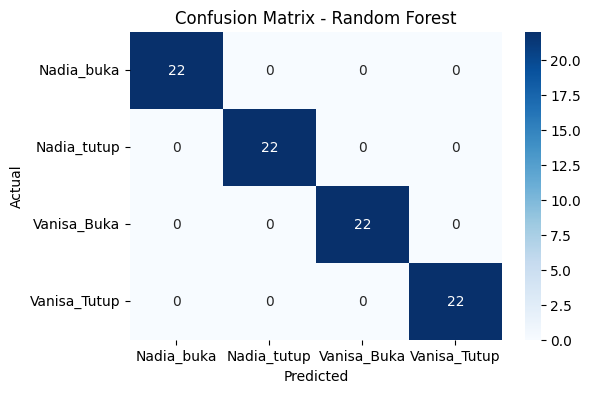


=== SVM (RBF Kernel) ===
Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Nadia_buka       1.00      1.00      1.00        22
 Nadia_tutup       1.00      1.00      1.00        22
 Vanisa_Buka       1.00      1.00      1.00        22
Vanisa_Tutup       1.00      1.00      1.00        22

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88



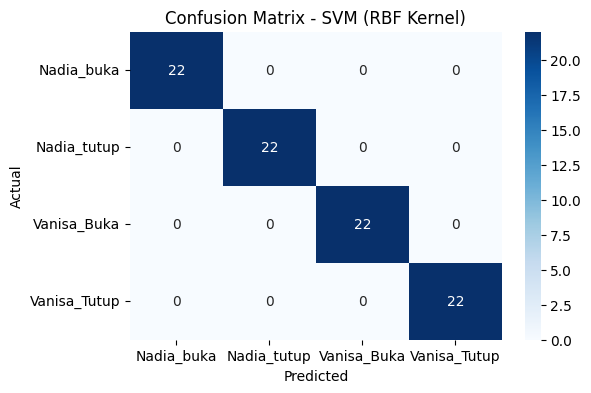


=== Naive Bayes ===
Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Nadia_buka       1.00      1.00      1.00        22
 Nadia_tutup       1.00      1.00      1.00        22
 Vanisa_Buka       1.00      1.00      1.00        22
Vanisa_Tutup       1.00      1.00      1.00        22

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88



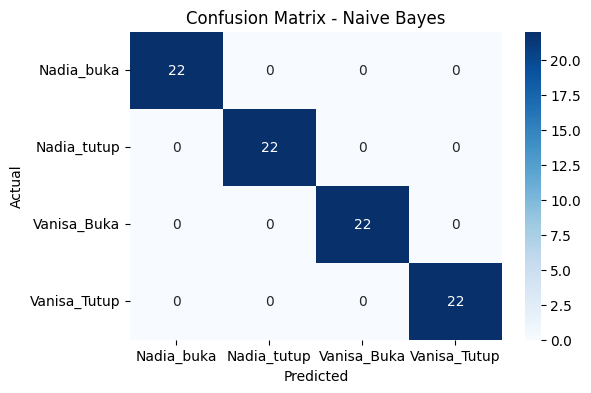


✅ Model terbaik: Random Forest dengan akurasi 1.0000
✅ Model tersimpan sebagai 'best_audio_model.pkl'


In [30]:
# ==================================================
# 🔹 TRAINING & PILIH MODEL TERBAIK DENGAN OUTPUT RAPI
# ==================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Inisialisasi model
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

best_acc = 0
best_model_name = None
best_model = None

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Training pakai data yang sudah dinormalisasi
    model.fit(X_train_scaled, y_train)
    
    # Prediksi pakai data test yang sudah dinormalisasi
    y_pred = model.predict(X_test_scaled)
    
    # Akurasi
    acc = accuracy_score(y_test, y_pred)
    print(f"Akurasi: {acc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Update model terbaik
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model

# Simpan model terbaik
joblib.dump(best_model, "best_audio_model.pkl")
print(f"\n✅ Model terbaik: {best_model_name} dengan akurasi {best_acc:.4f}")
print("✅ Model tersimpan sebagai 'best_audio_model.pkl'")


### Tahap 11 : Evaluasi Model Terbaik

📌 Akurasi Model Terbaik: 1.0000

📊 Classification Report:


,precision,recall,f1-score,support
Nadia_buka,1.0,1.0,1.0,22.0
Nadia_tutup,1.0,1.0,1.0,22.0
Vanisa_Buka,1.0,1.0,1.0,22.0
Vanisa_Tutup,1.0,1.0,1.0,22.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,88.0
weighted avg,1.0,1.0,1.0,88.0


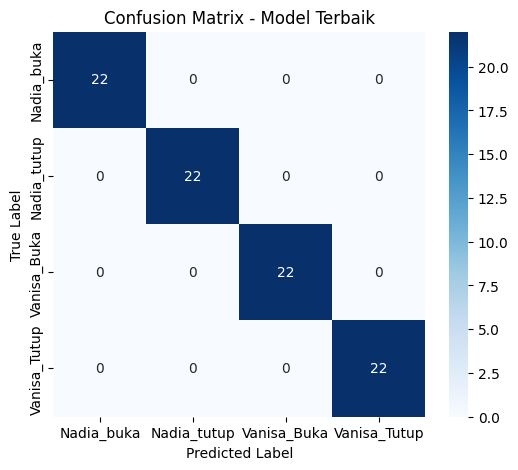

In [31]:
# ==================================================
# 🔹 EVALUASI MODEL TERBAIK (SETELAH TRAINING)
# ==================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Load model terbaik
best_model = joblib.load("best_audio_model.pkl")

# Gunakan data test yang sudah dinormalisasi
y_pred = best_model.predict(X_test_scaled)

# Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"📌 Akurasi Model Terbaik: {acc:.4f}\n")

# Classification report
print("📊 Classification Report:")
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()
display(df_report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title("Confusion Matrix - Model Terbaik")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Tahap 12: Prediksi Data Baru

In [32]:
# ==================================================
# 🔹 IMPORT LIBRARY
# ==================================================
import os
import numpy as np
import pandas as pd
import librosa
import joblib

# ==================================================
# 🔹 FUNGSIONAL EKSTRAKSI FITUR AUDIO
# ==================================================
def zero_crossing_rate(y):
    return np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)[0]

def rms(signal):
    return np.sqrt(np.mean(signal**2))

def spectral_centroid(y, sr):
    return np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

def spectral_bandwidth(y, sr):
    return np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))

def spectral_contrast(y, sr):
    return np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))

def mfcc_features(y, sr, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfccs, axis=1)

def extract_features(file_path):
    """Ekstraksi fitur untuk satu file audio"""
    y, sr = librosa.load(file_path, sr=22050)
    features = [
        zero_crossing_rate(y),
        rms(y),
        spectral_centroid(y, sr),
        spectral_bandwidth(y, sr),
        spectral_contrast(y, sr)
    ]
    mfccs = mfcc_features(y, sr)
    features.extend(mfccs.tolist())
    return np.array(features).reshape(1, -1)

# ==================================================
# 🔹 LOAD MODEL & SCALER
# ==================================================
model = joblib.load("best_audio_model.pkl")
scaler = joblib.load("scaler_audio.pkl")

# ==================================================
# 🔹 PREDIKSI SPEAKER BARU DENGAN THRESHOLD
# ==================================================
def predict_speaker(file_path, threshold=0.7):
    # Ekstrak fitur
    features = extract_features(file_path)
    
    # Pastikan jumlah fitur sesuai scaler
    if features.shape[1] != scaler.n_features_in_:
        print(f"❌ Jumlah fitur {features.shape[1]} tidak cocok dengan scaler ({scaler.n_features_in_})")
        return
    
    # Normalisasi
    features_scaled = scaler.transform(features)
    
    # Prediksi probabilitas
    probs = model.predict_proba(features_scaled)[0]
    max_prob = np.max(probs)
    pred_label = model.classes_[np.argmax(probs)]
    
    # Cek threshold
    if max_prob < threshold:
        print("❌ Speaker tidak dikenal")
        print(f"Confidence tertinggi: {max_prob:.2f}")
    else:
        print(f"✅ Prediksi Speaker: {pred_label}")
        print(f"Confidence: {max_prob:.2f}")

# ==================================================
# 🔹 CONTOH PENGGUNAAN
# ==================================================
file_new = "clean_audio/ulva_buka.wav"  # ganti dengan path file audio baru
predict_speaker(file_new, threshold=0.7)


❌ Speaker tidak dikenal
Confidence tertinggi: 0.57


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Tahap 13: Deployment

#### Tampilan UI dari streamlit file app.py

In [ ]:

# ============================================================
# 🎧 STREAMLIT APP — Prediksi Suara Buka/Tutup (Nadia & Vanisa Only)
# ============================================================

import streamlit as st
import numpy as np
import pandas as pd
import librosa
import librosa.display
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from streamlit_webrtc import webrtc_streamer, AudioProcessorBase, WebRtcMode

# ============================================================
# Konfigurasi Streamlit
# ============================================================
st.set_page_config(
    page_title="Prediksi Suara Buka/Tutup (Nadia & Vanisa Only)",
    page_icon="🎵",
    layout="centered",
)

# ============================================================
# Load model & scaler
# ============================================================
@st.cache_resource
def load_model_scaler():
    model = joblib.load("best_audio_model.pkl")
    scaler = joblib.load("scaler_audio.pkl")
    return model, scaler

model, scaler = load_model_scaler()

# ============================================================
# Fungsi ekstraksi fitur
# ============================================================
def zero_crossing_rate(y):
    return np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)[0]

def rms(signal):
    return np.sqrt(np.mean(signal**2))

def spectral_centroid(y, sr):
    return np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

def spectral_bandwidth(y, sr):
    return np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))

def spectral_contrast(y, sr):
    return np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))

def mfcc_features(y, sr, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfccs, axis=1)

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    features = [
        zero_crossing_rate(y),
        rms(y),
        spectral_centroid(y, sr),
        spectral_bandwidth(y, sr),
        spectral_contrast(y, sr),
    ]
    mfccs = mfcc_features(y, sr)
    features.extend(mfccs.tolist())
    return np.array(features).reshape(1, -1), y, sr

# ============================================================
# Prediksi (Locked Speaker: Nadia & Vanisa)
# ============================================================
def predict_audio(file_path=None, y=None, sr=None, threshold=0.6):
    if file_path:
        features, y, sr = extract_features(file_path)
    else:
        # Buat fitur dari waveform langsung
        features = [
            zero_crossing_rate(y),
            rms(y),
            spectral_centroid(y, sr),
            spectral_bandwidth(y, sr),
            spectral_contrast(y, sr),
        ]
        mfccs = mfcc_features(y, sr)
        features.extend(mfccs.tolist())
        features = np.array(features).reshape(1, -1)

    features_scaled = scaler.transform(features)
    probs = model.predict_proba(features_scaled)[0]
    labels = model.classes_

    idx_top = np.argmax(probs)
    pred_label = labels[idx_top]
    pred_prob = probs[idx_top]

    parts = pred_label.lower().split("_")
    speaker = parts[0] if len(parts) > 0 else "unknown"
    status = parts[1].capitalize() if len(parts) > 1 else "-"

    allowed = ["nadia", "vanisa"]
    if speaker not in allowed or pred_prob < threshold:
        speaker = "Unknown"
        status = "Tidak diketahui"

    return speaker.capitalize(), status, pred_prob, probs, labels, y, sr

# ============================================================
# UI Streamlit
# ============================================================
st.title("🎧 Prediksi Suara Buka/Tutup")
st.markdown(
    """
    <p style="font-size:16px;">Aplikasi ini hanya menerima suara dari <b>Nadia</b> dan <b>Vanisa</b>.<br>
    Jika suara lain terdeteksi, hasil akan menjadi <b>Unknown</b>.</p>
    """,
    unsafe_allow_html=True,
)

# 🧩 Slider threshold
st.sidebar.header("⚙️ Pengaturan Model")
threshold = st.sidebar.slider(
    "Ambang Confidence (Threshold)",
    min_value=0.3,
    max_value=0.9,
    value=0.6,
    step=0.05,
    help="Semakin tinggi nilainya, semakin ketat sistem dalam mengenali suara.",
)

# ============================================================
# Upload file audio
# ============================================================
uploaded_file = st.file_uploader("🎵 Upload file audio (.wav)", type=["wav"])
if uploaded_file:
    temp_path = "temp_audio.wav"
    with open(temp_path, "wb") as f:
        f.write(uploaded_file.read())

    st.audio(temp_path, format="audio/wav")
    with st.spinner("⏳ Memproses audio..."):
        speaker, status, prob, probs, labels, y, sr = predict_audio(temp_path, threshold)

    # Tampilkan hasil
    st.markdown("---")
    st.subheader("🎯 Hasil Prediksi")
    col1, col2 = st.columns(2)
    with col1:
        st.metric("Speaker", speaker)
    with col2:
        st.metric("Status Suara", status)
    st.metric("Confidence (%)", f"{prob*100:.2f}%")

    # Tabel probabilitas
    prob_df = pd.DataFrame({"Kelas": labels, "Probabilitas (%)": [round(float(p)*100, 2) for p in probs]}).sort_values("Probabilitas (%)", ascending=False)
    st.markdown("#### 📊 Probabilitas Tiap Kelas")
    st.table(prob_df.style.set_table_styles([{"selector": "th","props":[("text-align","center"),("font-weight","bold")]},{"selector":"td","props":[("text-align","center")]}]))

    # Waveform & Mel Spectrogram
    st.subheader("📈 Waveform Audio")
    fig, ax = plt.subplots(figsize=(8, 3))
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title("Waveform Audio", fontsize=12)
    st.pyplot(fig)

    st.subheader("🎛️ Mel Spectrogram")
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_dB = librosa.power_to_db(S, ref=np.max)
    fig, ax = plt.subplots(figsize=(10, 4))
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title("Mel Spectrogram", fontsize=12)
    st.pyplot(fig)

    # Distribusi probabilitas
    st.subheader("📉 Distribusi Probabilitas")
    plt.figure(figsize=(6, 4))
    sns.barplot(x="Kelas", y="Probabilitas (%)", data=prob_df)
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.tight_layout()
    st.pyplot(plt)

    os.remove(temp_path)

# ============================================================
# Rekam suara langsung dari browser
# ============================================================
st.markdown("---")
st.subheader("🎤 Rekam Suara Langsung")
webrtc_ctx = webrtc_streamer(
    key="audio",
    mode=WebRtcMode.SENDONLY,
    audio_receiver_size=256,
    media_stream_constraints={"audio": True, "video": False},
)

if webrtc_ctx.audio_receiver:
    import _queue
    audio_frames = []
    try:
        while True:
            frame = webrtc_ctx.audio_receiver.get_frame(block=False)
            audio_frames.append(frame)
    except _queue.Empty:
        pass

    if audio_frames:
        audio_data = np.concatenate([f.to_ndarray() for f in audio_frames], axis=0)
        if audio_data.ndim > 1:
            audio_data = np.mean(audio_data, axis=1)
        y = audio_data.astype(np.float32)
        sr = 44100

        with st.spinner("⏳ Memproses audio rekaman..."):
            speaker, status, prob, probs, labels, _, _ = predict_audio(y=y, sr=sr, threshold=threshold)

        # Tampilkan hasil rekaman
        st.markdown("---")
        st.subheader("🎯 Hasil Prediksi Rekaman")
        col1, col2 = st.columns(2)
        with col1:
            st.metric("Speaker", speaker)
        with col2:
            st.metric("Status Suara", status)
        st.metric("Confidence (%)", f"{prob*100:.2f}%")



#### Link web streamlit
- https://identifikasisuara-zogb6xjgeijnrw84vp8qgi.streamlit.app/